# 🌿 WeedScan — Automated Weed Detection in Crop Fields
### MSc Agriculture Analytics — IIRS Project 2026
**Group:** WeedScan  
**Member:** Maharshi K Patel (TS91248)

---

This notebook implements the complete WeedScan pipeline:
1. Environment setup & GPU verification
2. Dataset download via Roboflow API
3. Dataset exploration & class distribution
4. YOLOv8 model training (50 epochs)
5. Model validation (mAP@0.5, Precision, Recall)
6. Final testing on held-out test set
7. Inference with bounding box visualisation
8. Export weed detection coordinates to CSV
9. Training performance graphs

**Runtime:** Set to `GPU (T4)` via *Runtime → Change runtime type*

## ✅ Step 0 — GPU Verification

In [1]:
import torch

print("=" * 50)
print("WeedScan — Environment Check")
print("=" * 50)
print(f"PyTorch Version : {torch.__version__}")
print(f"CUDA Available  : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Device      : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU detected. Go to Runtime → Change runtime type → GPU")

print("=" * 50)

WeedScan — Environment Check
PyTorch Version : 2.11.0+cu128
CUDA Available  : True
GPU Device      : Tesla T4
GPU Memory      : 15.6 GB


## 📦 Step 1 — Install Dependencies

In [2]:
# Install Ultralytics YOLOv8 and Roboflow SDK
!pip install ultralytics roboflow --quiet

# Verify installation
import ultralytics
ultralytics.checks()

print("\n✅ All dependencies installed successfully.")

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)

✅ All dependencies installed successfully.


## 📥 Step 2 — Import Libraries

In [3]:
import os
import cv2
import yaml
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from IPython.display import display
from ultralytics import YOLO
from roboflow import Roboflow

# Reproducibility seed
random.seed(42)
np.random.seed(42)

print("✅ All libraries imported.")

✅ All libraries imported.


## 🌾 Step 3 — Download Dataset from Roboflow

> **Instructions:**  
> 1. Go to [roboflow.com](https://roboflow.com) and create a free account  
> 2. Search for a **Weed Detection** dataset (e.g. `weed-detection` or `crop-weed`)  
> 3. Export in **YOLOv8** format and copy your API key + project details below

In [4]:
# ─────────────────────────────────────────────────────────────
# 🔑 CONFIGURE YOUR ROBOFLOW CREDENTIALS HERE
# ─────────────────────────────────────────────────────────────
ROBOFLOW_API_KEY  = "hAKqZXwuQj6nwtbF3WNl"       # Paste your Roboflow API key
WORKSPACE_NAME    = "mrunal-ramanna-5c9iq"     # e.g. "weedscan-lab"
PROJECT_NAME      = "weed-detection-r67fp"       # e.g. "weed-detection"
DATASET_VERSION   = 1                         # Dataset version number
# ─────────────────────────────────────────────────────────────

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(WORKSPACE_NAME).project(PROJECT_NAME)
dataset = project.version(DATASET_VERSION).download("yolov8")

DATASET_PATH = dataset.location
print(f"\n✅ Dataset downloaded to: {DATASET_PATH}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Weed-detection-1 in yolov8:: 100%|██████████| 3334/3334 [00:01<00:00, 2163.89it/s]



✅ Dataset downloaded to: /content/Weed-detection-1


## 🔍 Step 4 — Dataset Exploration & Class Distribution

In [5]:
# ── Read dataset YAML ──────────────────────────────────────────
yaml_path = os.path.join(DATASET_PATH, "data.yaml")

with open(yaml_path, "r") as f:
    data_cfg = yaml.safe_load(f)

CLASS_NAMES = data_cfg.get("names", [])
NUM_CLASSES = data_cfg.get("nc", len(CLASS_NAMES))

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Train path : {data_cfg.get('train')}")
print(f"Val path   : {data_cfg.get('val')}")
print(f"Test path  : {data_cfg.get('test', 'Not defined')}")

Classes (1): ['0 ridderzuring']
Train path : ../train/images
Val path   : ../valid/images
Test path  : ../test/images



📊 Dataset Summary
--------------------------------------------------
TRAIN    | 1163 images | {'0 ridderzuring': 2937}
VALID    |  332 images | {'0 ridderzuring': 867}
TEST     |  166 images | {'0 ridderzuring': 395}


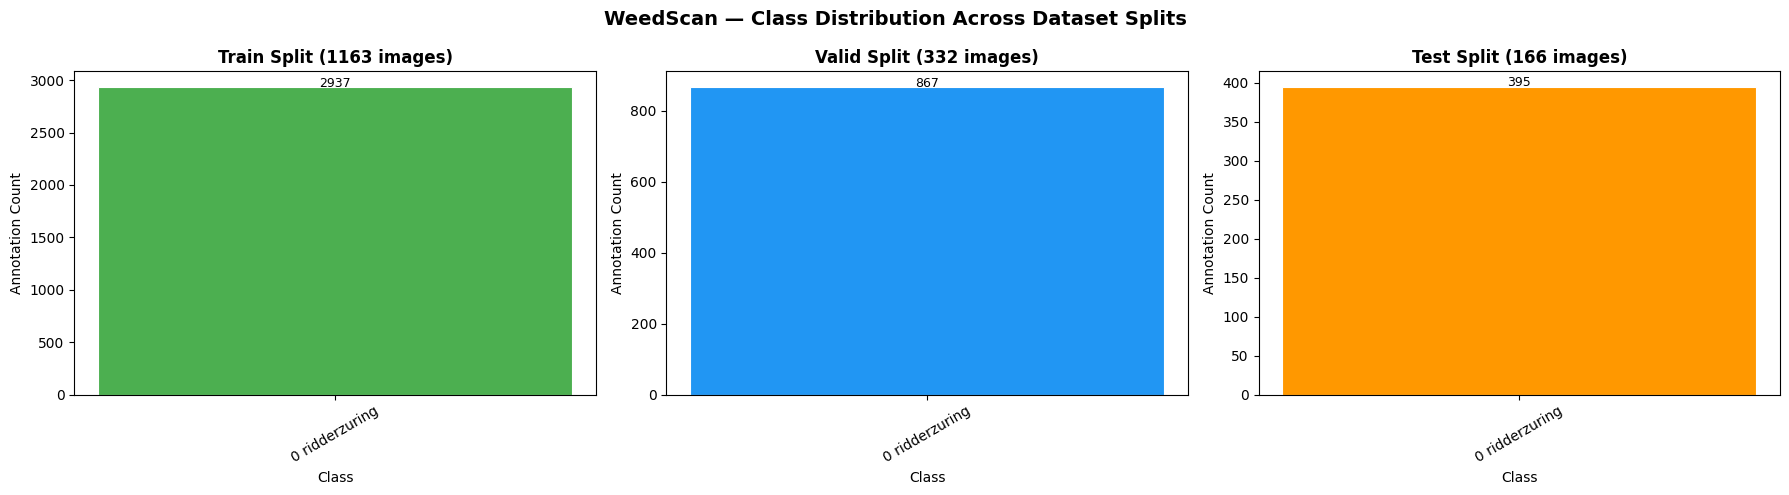


✅ Class distribution chart saved.


In [6]:
def count_labels_in_split(split_name):
    """Count bounding box instances per class in a dataset split."""
    labels_dir = os.path.join(DATASET_PATH, split_name, "labels")
    if not os.path.exists(labels_dir):
        print(f"⚠️  Labels directory not found: {labels_dir}")
        return {}, 0

    class_counts = {name: 0 for name in CLASS_NAMES}
    total_images = 0

    for label_file in glob.glob(os.path.join(labels_dir, "*.txt")):
        total_images += 1
        with open(label_file, "r") as f:
            for line in f.readlines():
                parts = line.strip().split()
                if parts:
                    class_idx = int(parts[0])
                    if class_idx < len(CLASS_NAMES):
                        class_counts[CLASS_NAMES[class_idx]] += 1

    return class_counts, total_images


# Count across all splits
splits = ["train", "valid", "test"]
split_colors = ["#4CAF50", "#2196F3", "#FF9800"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("WeedScan — Class Distribution Across Dataset Splits", fontsize=14, fontweight="bold")

print("\n📊 Dataset Summary")
print("-" * 50)

for ax, split, color in zip(axes, splits, split_colors):
    counts, n_images = count_labels_in_split(split)
    print(f"{split.upper():8s} | {n_images:4d} images | {dict(counts)}")

    if counts:
        ax.bar(counts.keys(), counts.values(), color=color, edgecolor="white", linewidth=0.8)
        ax.set_title(f"{split.capitalize()} Split ({n_images} images)", fontweight="bold")
        ax.set_xlabel("Class")
        ax.set_ylabel("Annotation Count")
        ax.tick_params(axis="x", rotation=30)
        for i, (k, v) in enumerate(counts.items()):
            ax.text(i, v + 0.5, str(v), ha="center", fontsize=9)
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.savefig("/content/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Class distribution chart saved.")

## 🖼️ Step 5 — Preview Sample Training Images

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


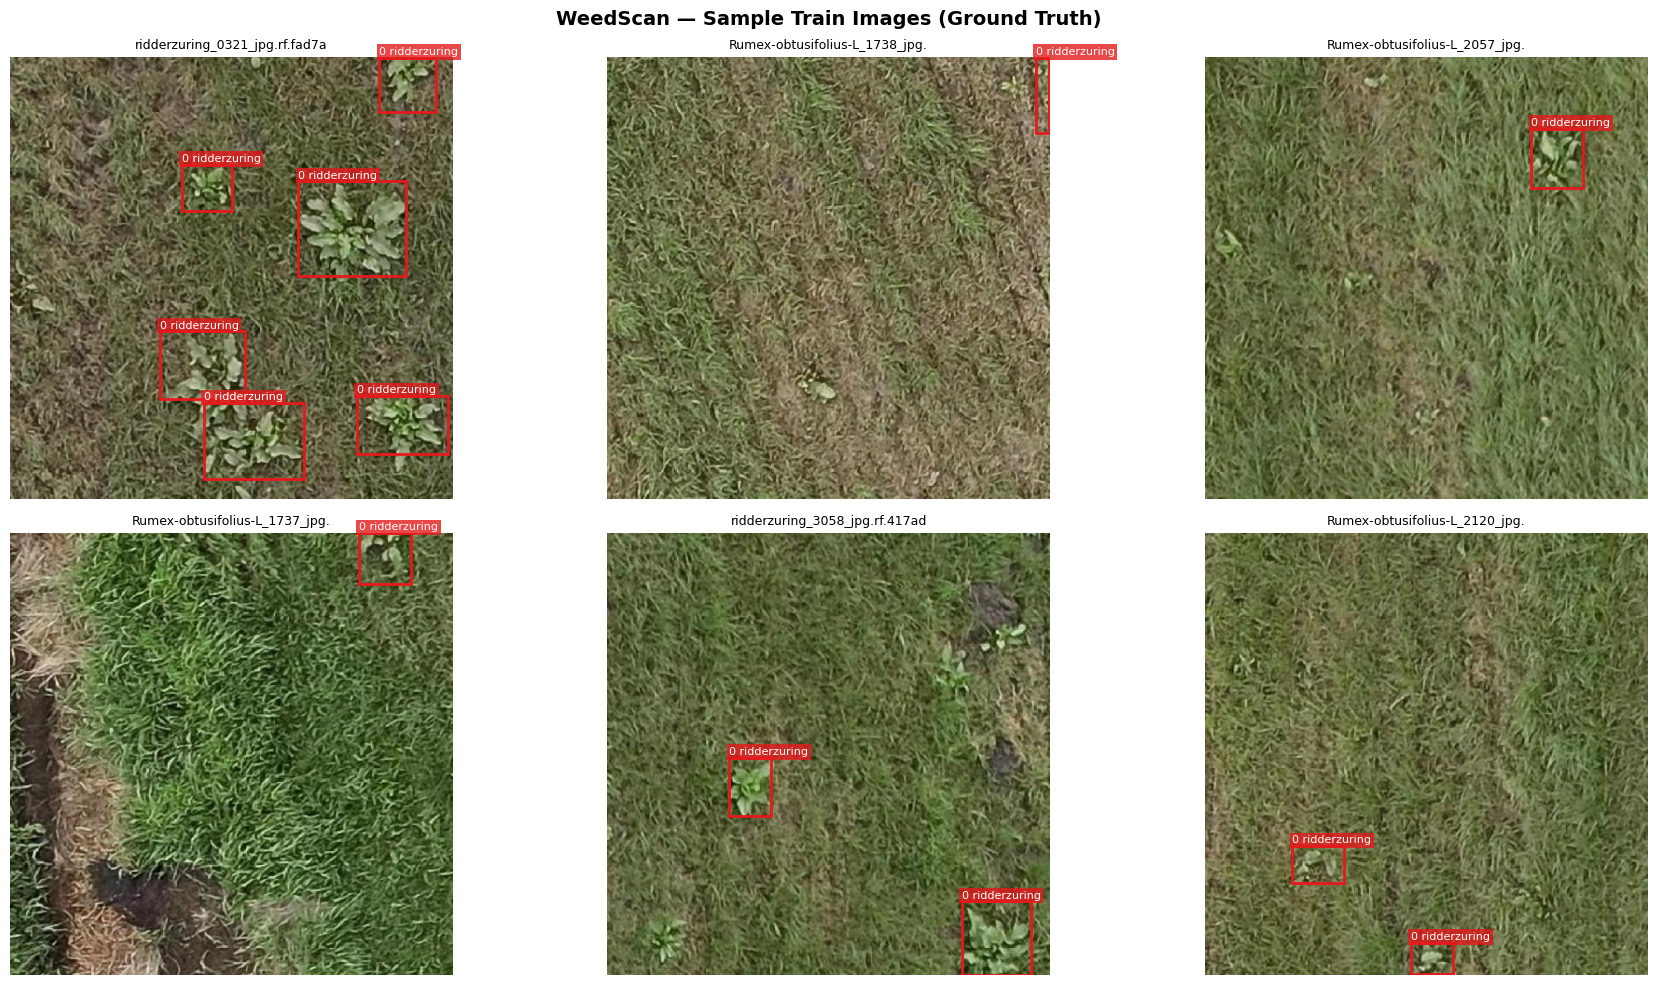

✅ Sample training images displayed.


In [7]:
def yolo_to_pixel(cx, cy, w, h, img_w, img_h):
    """Convert YOLO normalised bbox to pixel coordinates."""
    x1 = int((cx - w / 2) * img_w)
    y1 = int((cy - h / 2) * img_h)
    x2 = int((cx + w / 2) * img_w)
    y2 = int((cy + h / 2) * img_h)
    return x1, y1, x2, y2


def show_sample_images(split="train", n=6):
    """Display sample images with ground-truth bounding boxes."""
    img_dir = os.path.join(DATASET_PATH, split, "images")
    lbl_dir = os.path.join(DATASET_PATH, split, "labels")

    img_files = glob.glob(os.path.join(img_dir, "*"))
    samples = random.sample(img_files, min(n, len(img_files)))

    colors = plt.cm.get_cmap("Set1", NUM_CLASSES)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    fig.suptitle(f"WeedScan — Sample {split.capitalize()} Images (Ground Truth)",
                 fontsize=14, fontweight="bold")

    for ax, img_path in zip(axes, samples):
        img = np.array(Image.open(img_path).convert("RGB"))
        h, w = img.shape[:2]

        label_path = os.path.join(lbl_dir,
                                  Path(img_path).stem + ".txt")
        ax.imshow(img)

        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    parts = list(map(float, line.strip().split()))
                    cls_idx = int(parts[0])
                    x1, y1, x2, y2 = yolo_to_pixel(*parts[1:], w, h)
                    color = colors(cls_idx)[:3]
                    rect = patches.Rectangle(
                        (x1, y1), x2 - x1, y2 - y1,
                        linewidth=2, edgecolor=color, facecolor="none"
                    )
                    ax.add_patch(rect)
                    label = CLASS_NAMES[cls_idx] if cls_idx < len(CLASS_NAMES) else str(cls_idx)
                    ax.text(x1, y1 - 4, label, color="white", fontsize=8,
                            bbox=dict(facecolor=color, alpha=0.8, pad=2, edgecolor="none"))

        ax.set_title(Path(img_path).name[:30], fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("/content/sample_train_images.png", dpi=150, bbox_inches="tight")
    plt.show()


show_sample_images(split="train", n=6)
print("✅ Sample training images displayed.")

## 🏋️ Step 6 — Train YOLOv8 Model (50 Epochs)

> **Model choice:** `yolov8n.pt` (nano) is fast and suitable for Colab free GPU.  
> Swap for `yolov8s.pt` or `yolov8m.pt` for higher accuracy if using Colab Pro.

In [8]:
# ── Training Configuration ────────────────────────────────────
MODEL_VARIANT  = "yolov8n.pt"  # Options: yolov8n / yolov8s / yolov8m
EPOCHS         = 50
IMAGE_SIZE     = 640
BATCH_SIZE     = 16            # Reduce to 8 if CUDA OOM error occurs
PROJECT_DIR    = "/content/weedscan_runs"
RUN_NAME       = "weedscan_v1"
# ─────────────────────────────────────────────────────────────

# Load pre-trained YOLOv8 base model
model = YOLO(MODEL_VARIANT)

print(f"Starting WeedScan training...")
print(f"  Model   : {MODEL_VARIANT}")
print(f"  Epochs  : {EPOCHS}")
print(f"  Img Size: {IMAGE_SIZE}")
print(f"  Batch   : {BATCH_SIZE}")
print(f"  Data    : {yaml_path}")
print("=" * 50)

# Train
results = model.train(
    data=yaml_path,
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    project=PROJECT_DIR,
    name=RUN_NAME,
    device=0 if torch.cuda.is_available() else "cpu",
    exist_ok=True,
    plots=True,
    verbose=True,
    patience=15,       # Early stopping patience
    save=True,
    save_period=10,    # Save checkpoint every 10 epochs
)

TRAIN_RUN_DIR = os.path.join(PROJECT_DIR, RUN_NAME)
BEST_WEIGHTS  = os.path.join(TRAIN_RUN_DIR, "weights", "best.pt")

print("\n" + "=" * 50)
print("✅ Training complete!")
print(f"Best weights saved at: {BEST_WEIGHTS}")

Starting WeedScan training...
  Model   : yolov8n.pt
  Epochs  : 50
  Img Size: 640
  Batch   : 16
  Data    : /content/Weed-detection-1/data.yaml
Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Weed-detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, mom

## 📈 Step 7 — Training Performance Graphs

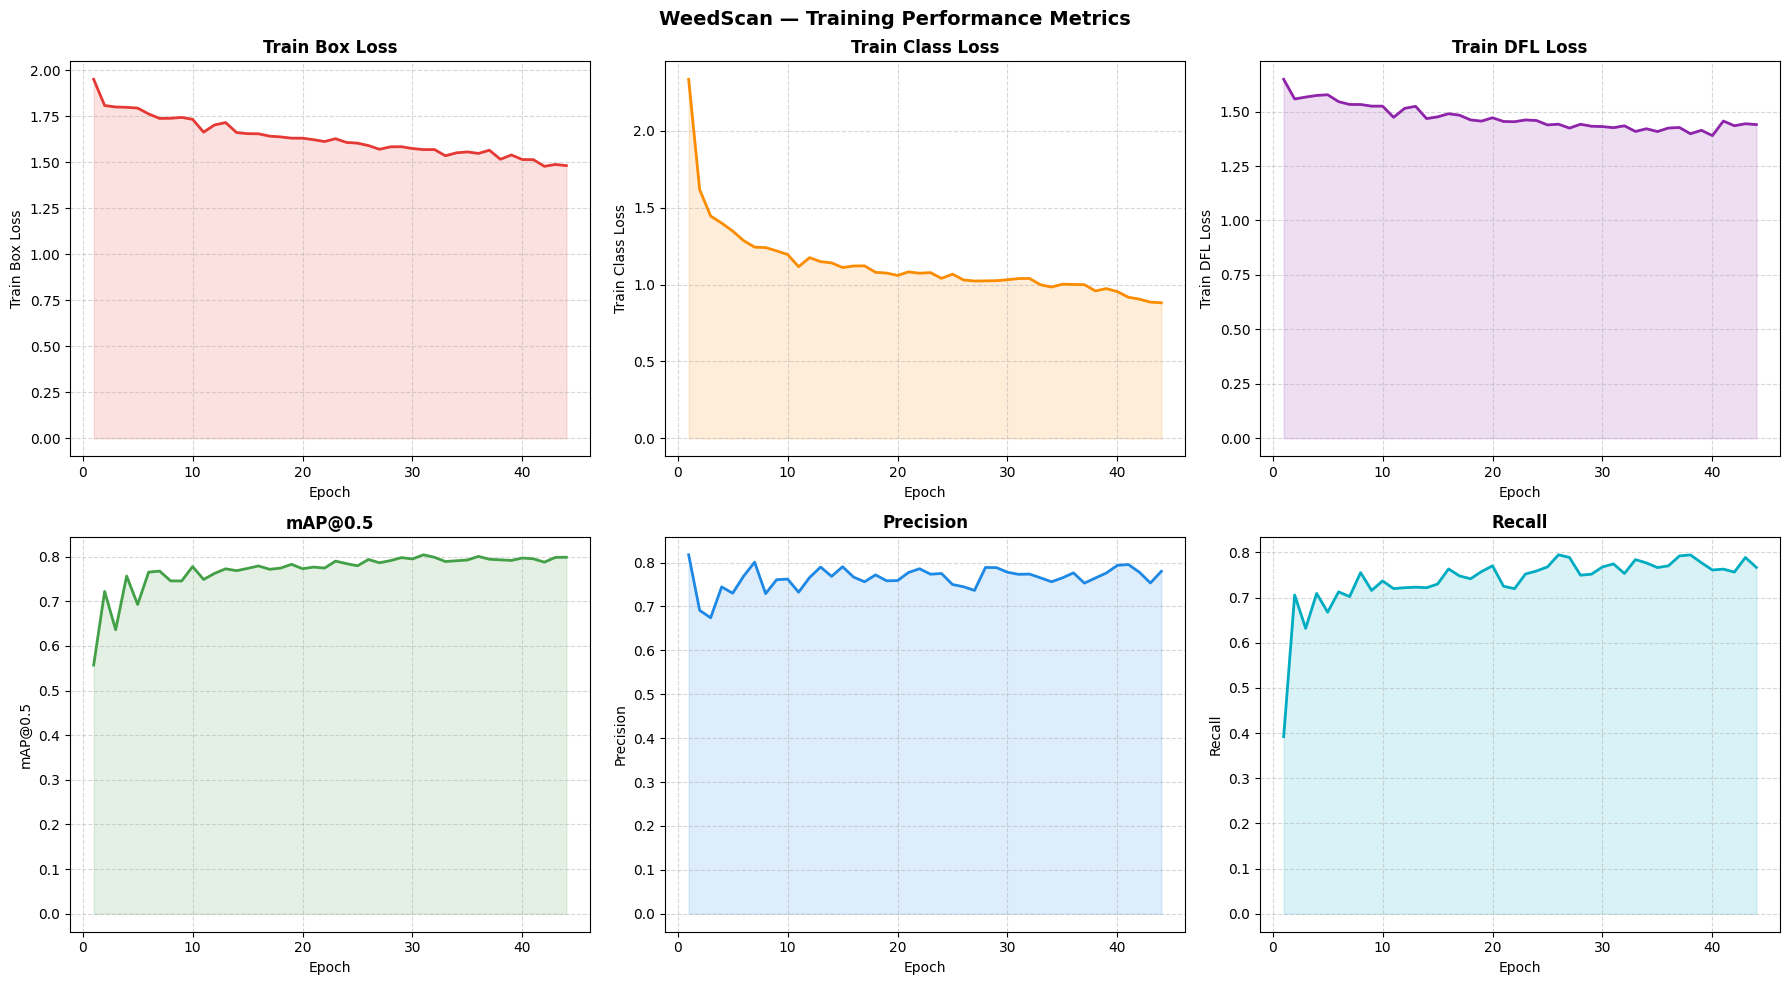

✅ Training performance graphs saved.


In [9]:
def plot_training_results(run_dir):
    """Plot training metrics from YOLOv8 results.csv."""
    csv_path = os.path.join(run_dir, "results.csv")
    if not os.path.exists(csv_path):
        print(f"⚠️  results.csv not found at {csv_path}")
        return

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()  # Remove whitespace

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("WeedScan — Training Performance Metrics", fontsize=14, fontweight="bold")

    plot_config = [
        ("train/box_loss",  "Train Box Loss",        "#E53935"),
        ("train/cls_loss",  "Train Class Loss",      "#FB8C00"),
        ("train/dfl_loss",  "Train DFL Loss",        "#8E24AA"),
        ("metrics/mAP50(B)","mAP@0.5",               "#43A047"),
        ("metrics/precision(B)", "Precision",        "#1E88E5"),
        ("metrics/recall(B)",    "Recall",            "#00ACC1"),
    ]

    for ax, (col, title, color) in zip(axes.flatten(), plot_config):
        if col in df.columns:
            ax.plot(df["epoch"], df[col], color=color, linewidth=2)
            ax.fill_between(df["epoch"], df[col], alpha=0.15, color=color)
            ax.set_title(title, fontweight="bold")
            ax.set_xlabel("Epoch")
            ax.set_ylabel(title)
            ax.grid(True, linestyle="--", alpha=0.5)
        else:
            ax.set_title(f"{title} (not available)", color="gray")
            ax.axis("off")

    plt.tight_layout()
    plt.savefig("/content/training_metrics.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Training performance graphs saved.")


plot_training_results(TRAIN_RUN_DIR)

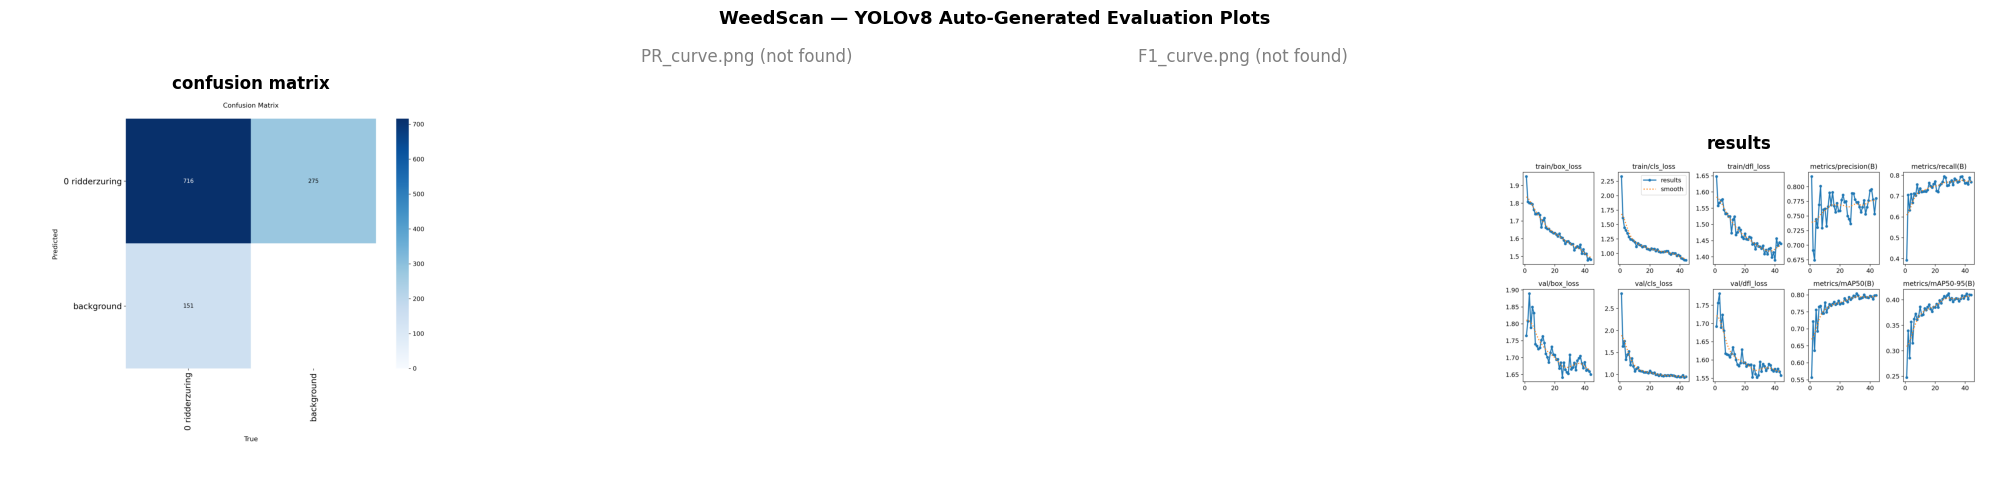

In [10]:
# ── Display YOLOv8 auto-generated plots if available ──────────
auto_plots = ["confusion_matrix.png", "PR_curve.png", "F1_curve.png", "results.png"]

fig, axes = plt.subplots(1, len(auto_plots), figsize=(20, 5))
fig.suptitle("WeedScan — YOLOv8 Auto-Generated Evaluation Plots",
             fontsize=13, fontweight="bold")

for ax, plot_name in zip(axes, auto_plots):
    plot_path = os.path.join(TRAIN_RUN_DIR, plot_name)
    if os.path.exists(plot_path):
        img = plt.imread(plot_path)
        ax.imshow(img)
        ax.set_title(plot_name.replace(".png", "").replace("_", " "), fontweight="bold")
    else:
        ax.set_title(f"{plot_name} (not found)", color="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 🧪 Step 8 — Validation (During Training Metrics)

In [11]:
# Load best model and run formal validation on validation split
best_model = YOLO(BEST_WEIGHTS)

val_results = best_model.val(
    data=yaml_path,
    split="val",
    imgsz=IMAGE_SIZE,
    device=0 if torch.cuda.is_available() else "cpu",
    plots=True,
    verbose=True,
)

# ── Print validation summary ──────────────────────────────────
map50    = val_results.box.map50
map50_95 = val_results.box.map
prec     = val_results.box.mp    # Mean precision
recall   = val_results.box.mr    # Mean recall

print("\n" + "=" * 50)
print("📊 Validation Results (Validation Split)")
print("=" * 50)
print(f"  mAP@0.5        : {map50:.4f}  (Target ≥ 0.70)  {'✅' if map50 >= 0.70 else '❌'}")
print(f"  mAP@0.5:0.95   : {map50_95:.4f}")
print(f"  Precision      : {prec:.4f}  (Target ≥ 0.75)  {'✅' if prec >= 0.75 else '❌'}")
print(f"  Recall         : {recall:.4f}  (Target ≥ 0.70)  {'✅' if recall >= 0.70 else '❌'}")
print("=" * 50)

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1962.9±564.4 MB/s, size: 80.8 KB)
val: Scanning /content/Weed-detection-1/valid/labels.cache... 332 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 332/332 81.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 3.7it/s 5.7s
                   all        332        867      0.789      0.751      0.795      0.412
Speed: 3.2ms preprocess, 4.6ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/runs/detect/val

📊 Validation Results (Validation Split)
  mAP@0.5        : 0.7955  (Target ≥ 0.70)  ✅
  mAP@0.5:0.95   : 0.4124
  Precision      : 0.7885  (Target ≥ 0.75)  ✅
  Recall         : 0.7509  (Target ≥ 0.70)  ✅


## 🧬 Step 9 — Final Test Evaluation (Held-Out Test Set)

> This is run **only once** after training is complete. The test set was never seen during training or validation.

In [12]:
test_results = best_model.val(
    data=yaml_path,
    split="test",
    imgsz=IMAGE_SIZE,
    device=0 if torch.cuda.is_available() else "cpu",
    plots=True,
    verbose=True,
)

t_map50  = test_results.box.map50
t_map    = test_results.box.map
t_prec   = test_results.box.mp
t_recall = test_results.box.mr

# Compute F1 Score
if (t_prec + t_recall) > 0:
    f1_score = 2 * (t_prec * t_recall) / (t_prec + t_recall)
else:
    f1_score = 0.0

print("\n" + "=" * 55)
print("🎯 WeedScan — FINAL TEST SET RESULTS")
print("=" * 55)
print(f"  mAP@0.5        : {t_map50:.4f}   (Target ≥ 0.70)  {'✅ PASS' if t_map50 >= 0.70 else '❌ FAIL'}")
print(f"  mAP@0.5:0.95   : {t_map:.4f}")
print(f"  Precision      : {t_prec:.4f}   (Target ≥ 0.70)  {'✅ PASS' if t_prec >= 0.75 else '❌ FAIL'}")
print(f"  Recall         : {t_recall:.4f}   (Target ≥ 0.70)  {'✅ PASS' if t_recall >= 0.70 else '❌ FAIL'}")
print(f"  F1-Score       : {f1_score:.4f}")
print("=" * 55)

all_pass = t_map50 >= 0.70 and t_prec >= 0.70 and t_recall >= 0.70
print(f"\n  Overall Status : {'🟢 MODEL ACCEPTED — Ready for deployment!' if all_pass else '🔴 Below acceptance threshold — consider more epochs or data augmentation.'}")
print("=" * 55)

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1441.7±360.2 MB/s, size: 76.6 KB)
val: Scanning /content/Weed-detection-1/test/labels... 166 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 166/166 1.9Kit/s 0.1s
val: New cache created: /content/Weed-detection-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.7it/s 4.0s
                   all        166        395      0.732      0.718      0.757      0.383
Speed: 4.0ms preprocess, 5.2ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/runs/detect/val-2

🎯 WeedScan — FINAL TEST SET RESULTS
  mAP@0.5        : 0.7571   (Target ≥ 0.70)  ✅ PASS
  mAP@0.5:0.95   : 0.3834
  Precision      : 0.7316   (Target ≥ 0.70)  ❌ FAIL
  Recall         : 0.7178   (Target ≥ 0.70)  ✅ PASS
  F1-Score       : 0.7247

  Overall Status : 🟢 MODEL ACCEPTED — Ready 

## 🔎 Step 10 — Inference on Test Images (Bounding Box Visualisation)

In [13]:
# ── Run inference on test images ──────────────────────────────
TEST_IMAGES_DIR = os.path.join(DATASET_PATH, "test", "images")
INFERENCE_CONF  = 0.25   # Confidence threshold
INFERENCE_IOU   = 0.45   # NMS IoU threshold

test_img_files = glob.glob(os.path.join(TEST_IMAGES_DIR, "*"))
print(f"Running inference on {len(test_img_files)} test images...")

# Run batch inference
inference_output = best_model.predict(
    source=TEST_IMAGES_DIR,
    imgsz=IMAGE_SIZE,
    conf=INFERENCE_CONF,
    iou=INFERENCE_IOU,
    save=True,
    save_txt=True,
    project=PROJECT_DIR,
    name="weedscan_inference",
    exist_ok=True,
    device=0 if torch.cuda.is_available() else "cpu",
    verbose=False,
)

INFERENCE_DIR = os.path.join(PROJECT_DIR, "weedscan_inference")
print(f"\n✅ Inference complete. Annotated images saved to: {INFERENCE_DIR}")
print(f"   Total detections across all images: {sum(len(r.boxes) for r in inference_output)}")

Running inference on 166 test images...
Results saved to /content/weedscan_runs/weedscan_inference
162 labels saved to /content/weedscan_runs/weedscan_inference/labels

✅ Inference complete. Annotated images saved to: /content/weedscan_runs/weedscan_inference
   Total detections across all images: 484


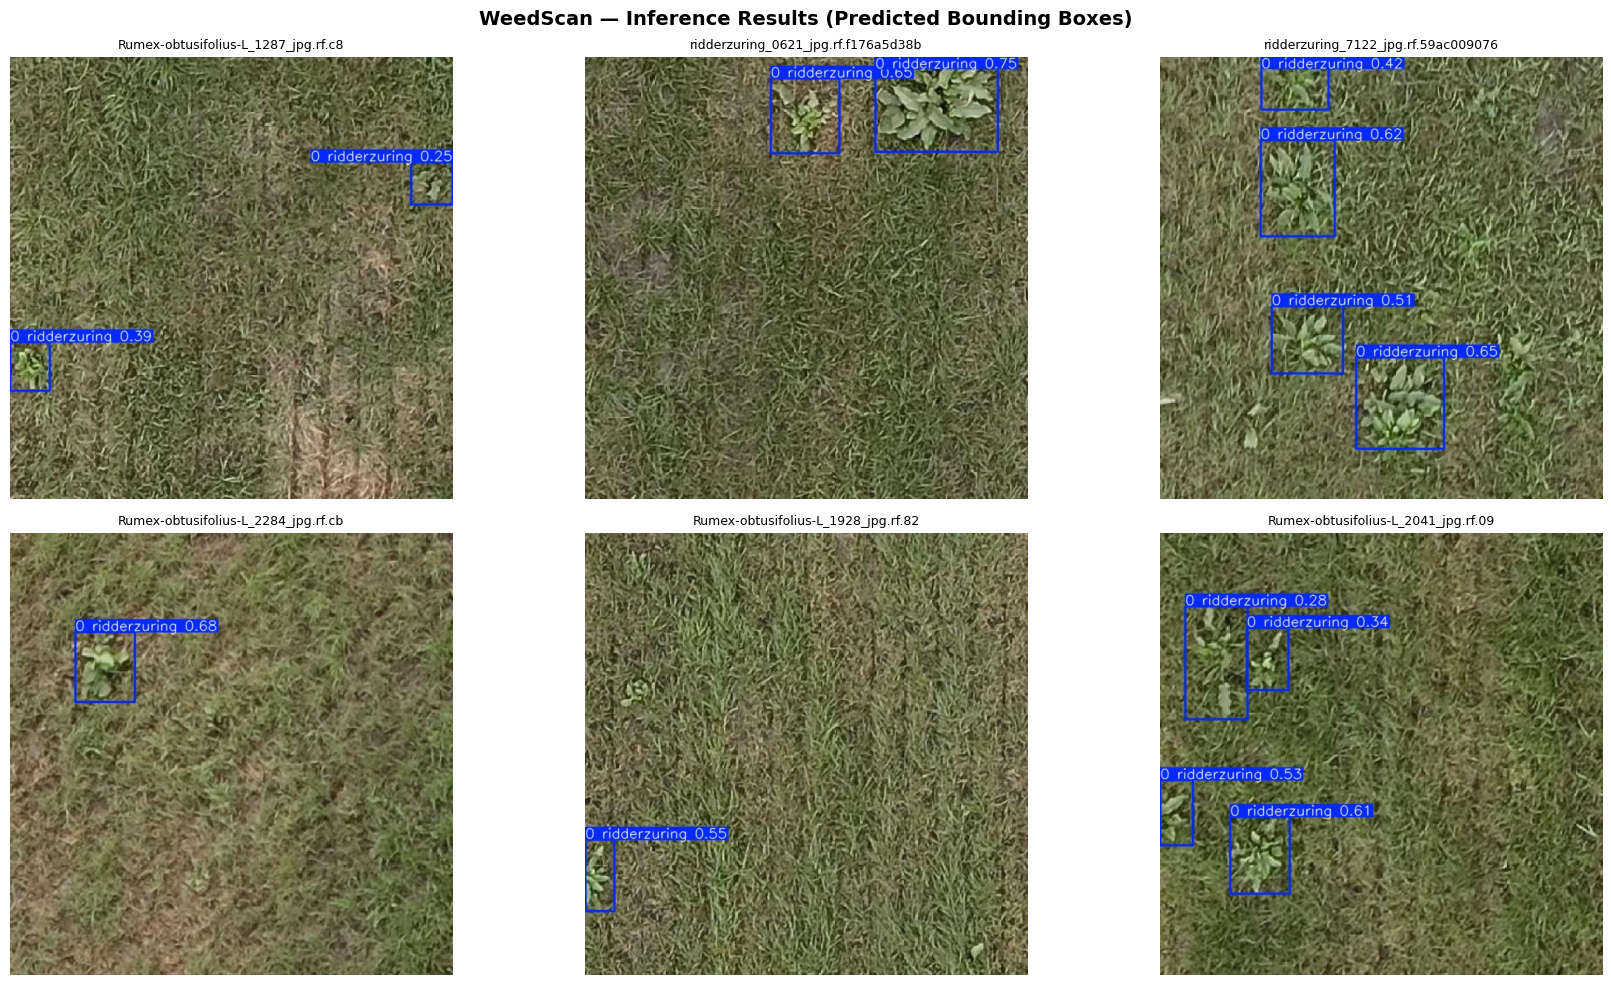

✅ Inference visualisations saved.


In [14]:
# ── Visualise 6 random inference results ─────────────────────
annotated_imgs = glob.glob(os.path.join(INFERENCE_DIR, "*.jpg")) + \
                 glob.glob(os.path.join(INFERENCE_DIR, "*.png"))

samples = random.sample(annotated_imgs, min(6, len(annotated_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.suptitle("WeedScan — Inference Results (Predicted Bounding Boxes)",
             fontsize=14, fontweight="bold")

for ax, img_path in zip(axes, samples):
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.set_title(Path(img_path).name[:35], fontsize=9)
    ax.axis("off")

for ax in axes[len(samples):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("/content/inference_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Inference visualisations saved.")

## 📄 Step 11 — Export Weed Detection Coordinates to CSV

Exports all detected weed bounding box coordinates, class labels, and confidence scores from the test inference run. This CSV can be used to generate **site-specific herbicide spraying maps**.

In [15]:
def export_detections_to_csv(predictions, class_names, output_path):
    """
    Export YOLOv8 inference results to a structured CSV file.

    Columns:
      image_name   — filename of the source image
      detection_id — sequential detection index per image
      class_id     — numeric class index
      class_name   — human-readable class label
      confidence   — model confidence score (0–1)
      x_center_px  — bounding box centre X in pixels
      y_center_px  — bounding box centre Y in pixels
      width_px     — bounding box width in pixels
      height_px    — bounding box height in pixels
      x1, y1       — top-left corner (pixels)
      x2, y2       — bottom-right corner (pixels)
      x_norm       — normalised centre X (0–1, for GPS mapping)
      y_norm       — normalised centre Y (0–1, for GPS mapping)
    """
    records = []

    for result in predictions:
        img_name = Path(result.path).name
        img_h, img_w = result.orig_shape

        for det_id, box in enumerate(result.boxes):
            cls_id   = int(box.cls.item())
            conf     = float(box.conf.item())
            x1, y1, x2, y2 = box.xyxy[0].tolist()

            cx_px = (x1 + x2) / 2
            cy_px = (y1 + y2) / 2
            w_px  = x2 - x1
            h_px  = y2 - y1

            records.append({
                "image_name"   : img_name,
                "detection_id" : det_id + 1,
                "class_id"     : cls_id,
                "class_name"   : class_names[cls_id] if cls_id < len(class_names) else f"class_{cls_id}",
                "confidence"   : round(conf, 4),
                "x_center_px"  : round(cx_px, 2),
                "y_center_px"  : round(cy_px, 2),
                "width_px"     : round(w_px, 2),
                "height_px"    : round(h_px, 2),
                "x1"           : round(x1, 2),
                "y1"           : round(y1, 2),
                "x2"           : round(x2, 2),
                "y2"           : round(y2, 2),
                "x_norm"       : round(cx_px / img_w, 4),
                "y_norm"       : round(cy_px / img_h, 4),
            })

    df = pd.DataFrame(records)
    df.to_csv(output_path, index=False)
    return df


# Export
CSV_OUTPUT_PATH = "/content/weedscan_detections.csv"

detections_df = export_detections_to_csv(
    predictions=inference_output,
    class_names=CLASS_NAMES,
    output_path=CSV_OUTPUT_PATH,
)

print("\n" + "=" * 55)
print("📄 WeedScan Detection Coordinates — CSV Export")
print("=" * 55)
print(f"  Total detections : {len(detections_df)}")
print(f"  Unique images    : {detections_df['image_name'].nunique()}")
print(f"  Saved to         : {CSV_OUTPUT_PATH}")
print("=" * 55)

print("\n📋 Sample rows:")
display(detections_df.head(10))


📄 WeedScan Detection Coordinates — CSV Export
  Total detections : 484
  Unique images    : 162
  Saved to         : /content/weedscan_detections.csv

📋 Sample rows:


,image_name,detection_id,class_id,class_name,confidence,x_center_px,y_center_px,width_px,height_px,x1,y1,x2,y2,x_norm,y_norm
0,Rumex-obtusifolius-L_0047_jpg.rf.f95290fc1964e...,1,0,0 ridderzuring,0.3934,169.54,211.11,50.14,63.83,144.47,179.19,194.61,243.02,0.2649,0.3299
1,Rumex-obtusifolius-L_0054_jpg.rf.922ae6c3af3c0...,1,0,0 ridderzuring,0.6245,560.74,487.70,95.25,110.31,513.12,432.54,608.36,542.85,0.8762,0.7620
2,Rumex-obtusifolius-L_0058_jpg.rf.fa99c164126db...,1,0,0 ridderzuring,0.7480,498.93,151.50,104.51,119.54,446.67,91.73,551.18,211.27,0.7796,0.2367
3,Rumex-obtusifolius-L_0058_jpg.rf.fa99c164126db...,2,0,0 ridderzuring,0.6730,249.71,250.01,107.29,118.72,196.06,190.65,303.36,309.37,0.3902,0.3906
4,Rumex-obtusifolius-L_0058_jpg.rf.fa99c164126db...,3,0,0 ridderzuring,0.6666,242.32,538.30,117.63,89.66,183.51,493.46,301.14,583.13,0.3786,0.8411
5,Rumex-obtusifolius-L_0058_jpg.rf.fa99c164126db...,4,0,0 ridderzuring,0.4026,261.89,622.65,118.48,33.88,202.65,605.71,321.13,639.59,0.4092,0.9729
6,Rumex-obtusifolius-L_0061_jpg.rf.3b87d167c2e4e...,1,0,0 ridderzuring,0.7789,578.32,67.22,122.70,132.62,516.97,0.92,639.67,133.53,0.9036,0.1050
7,Rumex-obtusifolius-L_0061_jpg.rf.3b87d167c2e4e...,2,0,0 ridderzuring,0.7307,601.92,476.89,75.86,140.75,563.99,406.51,639.85,547.26,0.9405,0.7451
8,Rumex-obtusifolius-L_0061_jpg.rf.3b87d167c2e4e...,3,0,0 ridderzuring,0.7101,75.45,238.00,105.11,142.39,22.89,166.81,128.01,309.20,0.1179,0.3719
9,Rumex-obtusifolius-L_0061_jpg.rf.3b87d167c2e4e...,4,0,0 ridderzuring,0.6601,519.10,395.92,84.83,108.93,476.69,341.46,561.52,450.39,0.8111,0.6186



📊 Detections per Class:


,class_name,count,avg_conf,min_conf,max_conf
0,0 ridderzuring,484,0.528,0.2522,0.8003


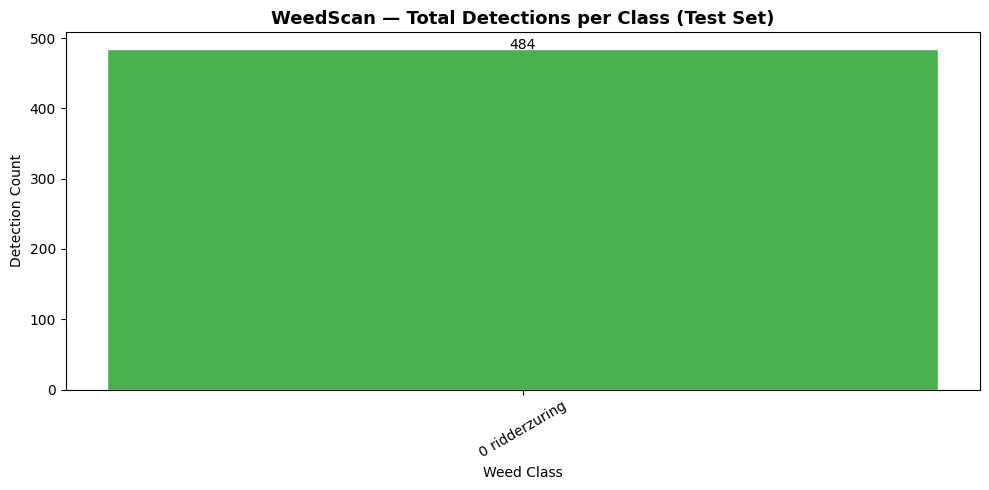

In [16]:
# ── Detection statistics per class ────────────────────────────
if not detections_df.empty:
    print("\n📊 Detections per Class:")
    class_summary = detections_df.groupby("class_name").agg(
        count=("detection_id", "count"),
        avg_conf=("confidence", "mean"),
        min_conf=("confidence", "min"),
        max_conf=("confidence", "max"),
    ).reset_index()
    class_summary["avg_conf"] = class_summary["avg_conf"].round(4)
    display(class_summary)

    # Bar chart of detections per class
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(class_summary["class_name"], class_summary["count"],
           color="#4CAF50", edgecolor="white")
    ax.set_title("WeedScan — Total Detections per Class (Test Set)",
                 fontweight="bold", fontsize=13)
    ax.set_xlabel("Weed Class")
    ax.set_ylabel("Detection Count")
    ax.tick_params(axis="x", rotation=30)
    for i, row in class_summary.iterrows():
        ax.text(i, row["count"] + 0.5, str(row["count"]), ha="center", fontsize=10)
    plt.tight_layout()
    plt.savefig("/content/detections_per_class.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("⚠️  No detections found. Try lowering INFERENCE_CONF threshold.")

## 📊 Step 12 — Final Results Summary Dashboard

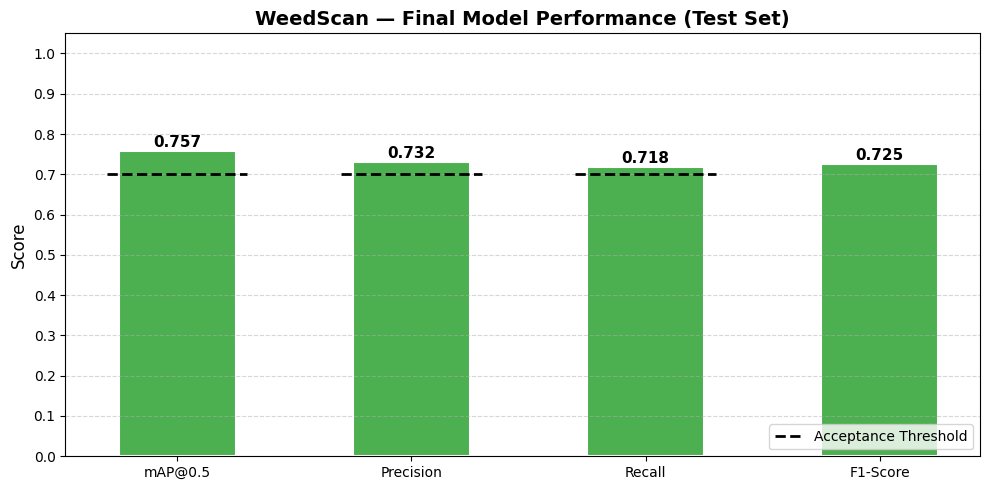


✅ Final metrics dashboard saved.


In [27]:
metrics = {
    "mAP@0.5"  : (t_map50,  0.70, "Higher is better"),
    "Precision" : (t_prec,   0.70, "Higher is better"),
    "Recall"    : (t_recall, 0.70, "Higher is better"),
    "F1-Score"  : (f1_score, None, "Harmonic mean of P & R"),
}

fig, ax = plt.subplots(figsize=(10, 5))
metric_names = list(metrics.keys())
values  = [metrics[m][0] for m in metric_names]
targets = [metrics[m][1] for m in metric_names]
colors  = ["#4CAF50" if (t is None or v >= t) else "#E53935"
           for v, t in zip(values, targets)]

bars = ax.bar(metric_names, values, color=colors, edgecolor="white", linewidth=1.5, width=0.5)

# Target lines
for i, (name, (val, target, _)) in enumerate(metrics.items()):
    if target:
        ax.hlines(target, i - 0.3, i + 0.3, colors="black",
                  linewidth=2, linestyles="--", label="Target" if i == 0 else "")
    ax.text(i, val + 0.01, f"{val:.3f}", ha="center", fontweight="bold", fontsize=11)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("WeedScan — Final Model Performance (Test Set)",
             fontsize=14, fontweight="bold")
ax.legend(["Acceptance Threshold"], loc="lower right")
ax.set_yticks([i / 10 for i in range(11)])
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("/content/final_metrics_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ Final metrics dashboard saved.")

## 💾 Step 13 — Save & Download All Outputs

In [18]:
import shutil, zipfile

OUTPUT_COLLECTION = "/content/WeedScan_Outputs"
os.makedirs(OUTPUT_COLLECTION, exist_ok=True)

# ── Files to collect ──────────────────────────────────────────
output_files = {
    BEST_WEIGHTS                                : "weights/best.pt",
    "/content/weedscan_detections.csv"          : "outputs/weedscan_detections.csv",
    "/content/class_distribution.png"           : "results/class_distribution.png",
    "/content/sample_train_images.png"          : "results/sample_train_images.png",
    "/content/training_metrics.png"             : "results/training_metrics.png",
    "/content/inference_results.png"            : "results/inference_results.png",
    "/content/detections_per_class.png"         : "results/detections_per_class.png",
    "/content/final_metrics_dashboard.png"      : "results/final_metrics_dashboard.png",
    os.path.join(TRAIN_RUN_DIR, "confusion_matrix.png") : "results/confusion_matrix.png",
    os.path.join(TRAIN_RUN_DIR, "PR_curve.png")         : "results/PR_curve.png",
    os.path.join(TRAIN_RUN_DIR, "results.csv")          : "results/training_log.csv",
}

for src, dest_rel in output_files.items():
    dest = os.path.join(OUTPUT_COLLECTION, dest_rel)
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    if os.path.exists(src):
        shutil.copy2(src, dest)
        print(f"  ✅ Copied: {dest_rel}")
    else:
        print(f"  ⚠️  Not found (skipped): {src}")

# ── Zip all outputs ───────────────────────────────────────────
zip_path = "/content/WeedScan_Outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(OUTPUT_COLLECTION):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, OUTPUT_COLLECTION)
            zf.write(file_path, arcname)

print(f"\n✅ All outputs zipped to: {zip_path}")

# ── Download prompt ───────────────────────────────────────────
from google.colab import files
print("\n📥 Downloading outputs ZIP...")
files.download(zip_path)
print("✅ Download initiated.")

  ✅ Copied: weights/best.pt
  ✅ Copied: outputs/weedscan_detections.csv
  ✅ Copied: results/class_distribution.png
  ✅ Copied: results/sample_train_images.png
  ✅ Copied: results/training_metrics.png
  ✅ Copied: results/inference_results.png
  ✅ Copied: results/detections_per_class.png
  ✅ Copied: results/final_metrics_dashboard.png
  ✅ Copied: results/confusion_matrix.png
  ⚠️  Not found (skipped): /content/weedscan_runs/weedscan_v1/PR_curve.png
  ✅ Copied: results/training_log.csv

✅ All outputs zipped to: /content/WeedScan_Outputs.zip

📥 Downloading outputs ZIP...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download initiated.


🛸 WeedScan — Custom Drone Image Inference
✅ Loaded trained model: /content/weedscan_runs/weedscan_v1/weights/best.pt

📤 Please upload your drone/field image (JPG or PNG):


Saving Screenshot 2026-03-27 at 3.25.10 PM.png to Screenshot 2026-03-27 at 3.25.10 PM.png

📷 Image received: Screenshot 2026-03-27 at 3.25.10 PM.png
   Size: 2147.0 KB

🔍 Running weed detection  (conf=0.25, iou=0.45)...


Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.


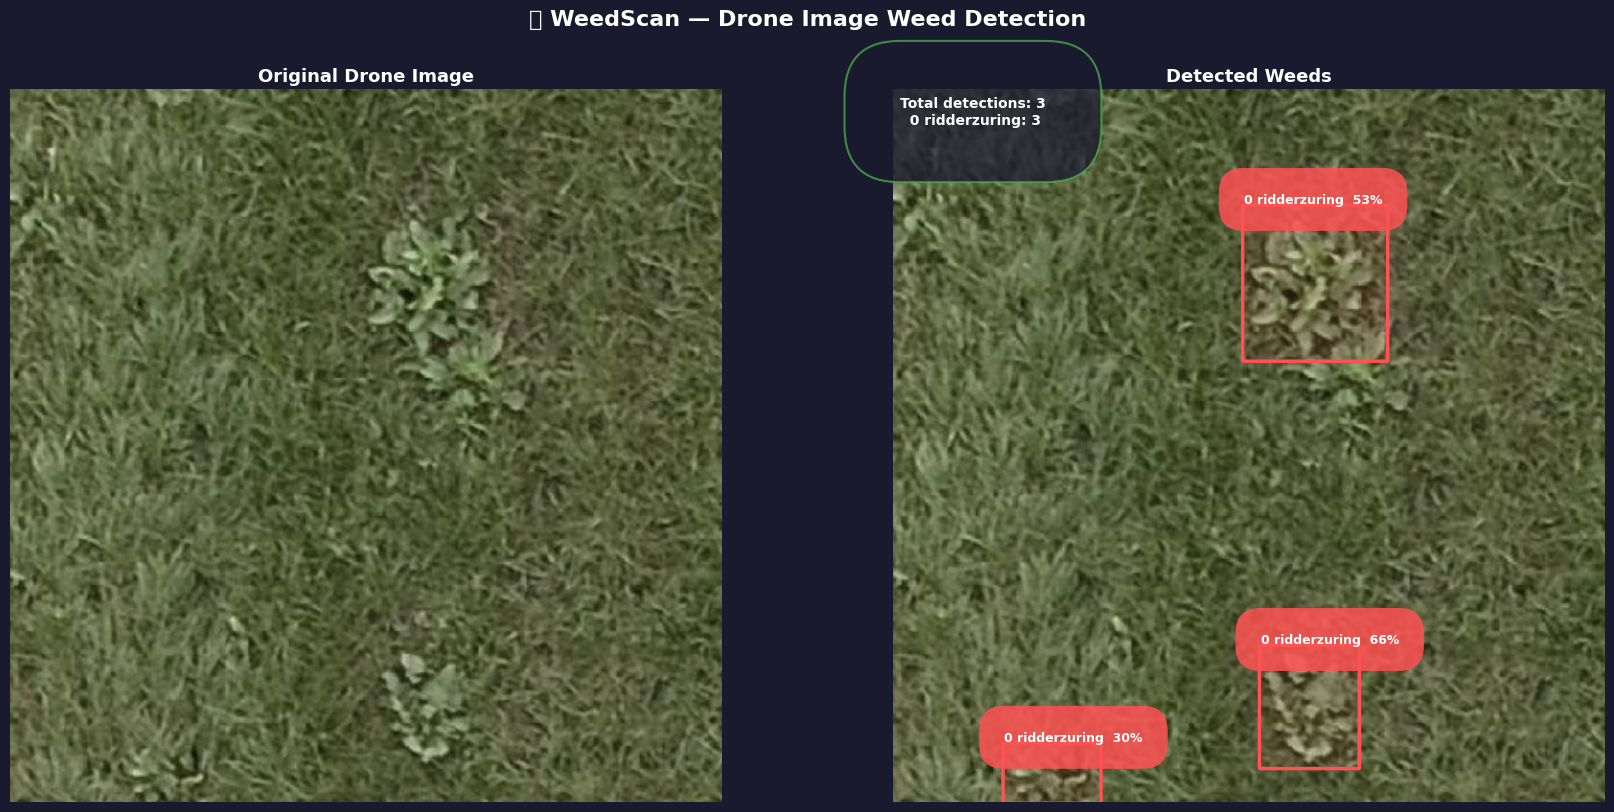


📊 Detection Results
  Total weeds detected : 3
    0 ridderzuring           : 3

  Result image saved : /content/custom_inference/detected_Screenshot 2026-03-27 at 3.25.10 PM.png

📥 Downloading result image...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from IPython.display import display as ipy_display
from google.colab import files
from ultralytics import YOLO

# ── Configuration ─────────────────────────────────────────────
INFERENCE_CONF   = 0.25   # Confidence threshold (lower = more detections)
INFERENCE_IOU    = 0.45   # IoU threshold for NMS
OUTPUT_DIR       = "/content/custom_inference"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Colour palette for classes ────────────────────────────────
PALETTE = [
    (255,  82,  82), (255, 167,  38), ( 38, 198, 218),
    (102, 187, 106), (171, 100, 228), (255, 238,  88),
    ( 66, 165, 245), (255, 112, 126), ( 77, 208, 225),
]

def get_color(class_idx):
    return PALETTE[class_idx % len(PALETTE)]


def draw_detections(image_path, results, class_names, save_path):
    """Draw bounding boxes on image and save result."""
    img = np.array(Image.open(image_path).convert("RGB"))
    img_h, img_w = img.shape[:2]

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.patch.set_facecolor("#1a1a2e")
    fig.suptitle(
        "🌿 WeedScan — Drone Image Weed Detection",
        fontsize=16, fontweight="bold", color="white", y=1.01
    )

    # Left: original
    axes[0].imshow(img)
    axes[0].set_title("Original Drone Image", color="white", fontweight="bold", fontsize=13)
    axes[0].axis("off")

    # Right: with detections
    axes[1].imshow(img)
    axes[1].set_title("Detected Weeds", color="white", fontweight="bold", fontsize=13)
    axes[1].axis("off")

    detection_summary = {}

    for r in results:
        boxes = r.boxes
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf  = float(box.conf[0])
            cls_i = int(box.cls[0])
            label = class_names[cls_i] if cls_i < len(class_names) else f"class_{cls_i}"
            color = [c / 255 for c in get_color(cls_i)]

            rect = patches.FancyBboxPatch(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2.5, edgecolor=color,
                facecolor=(*color[:3], 0.08),
                boxstyle="round,pad=2"
            )
            axes[1].add_patch(rect)

            tag = f"{label}  {conf:.0%}"
            axes[1].text(
                x1, y1 - 6, tag,
                color="white", fontsize=9, fontweight="bold",
                bbox=dict(facecolor=color, alpha=0.85, pad=3,
                          edgecolor="none", boxstyle="round,pad=2")
            )

            detection_summary[label] = detection_summary.get(label, 0) + 1

    # Overlay summary text on detection panel
    total = sum(detection_summary.values())
    summary_lines = [f"Total detections: {total}"]
    for cls_name, cnt in sorted(detection_summary.items(), key=lambda x: -x[1]):
        summary_lines.append(f"  {cls_name}: {cnt}")

    axes[1].text(
        0.01, 0.99, "\n".join(summary_lines),
        transform=axes[1].transAxes,
        fontsize=10, color="white", fontweight="bold",
        verticalalignment="top",
        bbox=dict(facecolor="#1a1a2e", alpha=0.75, pad=8,
                  edgecolor="#4CAF50", linewidth=1.5, boxstyle="round,pad=4")
    )

    for ax in axes:
        ax.set_facecolor("#1a1a2e")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight",
                facecolor="#1a1a2e")
    plt.show()
    return detection_summary


# ── Load trained model ─────────────────────────────────────────
print("=" * 55)
print("🛸 WeedScan — Custom Drone Image Inference")
print("=" * 55)

try:
    weed_model = YOLO(BEST_WEIGHTS)
    print(f"✅ Loaded trained model: {BEST_WEIGHTS}")
except Exception:
    print("⚠️  BEST_WEIGHTS not found — loading YOLOv8 base model.")
    print("   Run Step 6 first to train, or update BEST_WEIGHTS path below.")
    BEST_WEIGHTS = "/content/weedscan_runs/weedscan_v1/weights/best.pt"
    if os.path.exists(BEST_WEIGHTS):
        weed_model = YOLO(BEST_WEIGHTS)
    else:
        weed_model = YOLO("yolov8n.pt")  # fallback
        print("   ⚠️  Using base YOLOv8 — results will not be weed-specific.")

# ── Upload drone image ─────────────────────────────────────────
print("\n📤 Please upload your drone/field image (JPG or PNG):")
uploaded = files.upload()

if not uploaded:
    print("⚠️  No file uploaded. Please re-run this cell and select an image.")
else:
    for filename, data in uploaded.items():
        # Save uploaded file
        upload_path = os.path.join(OUTPUT_DIR, filename)
        with open(upload_path, "wb") as f:
            f.write(data)
        print(f"\n📷 Image received: {filename}")
        print(f"   Size: {len(data) / 1024:.1f} KB")

        # ── Run inference ──────────────────────────────────────
        print(f"\n🔍 Running weed detection  (conf={INFERENCE_CONF}, iou={INFERENCE_IOU})...")
        preds = weed_model.predict(
            source=upload_path,
            conf=INFERENCE_CONF,
            iou=INFERENCE_IOU,
            save=False,
            verbose=False,
        )

        # ── Get class names ────────────────────────────────────
        try:
            det_class_names = CLASS_NAMES
        except NameError:
            det_class_names = list(weed_model.names.values())

        # ── Visualise & print results ──────────────────────────
        result_img_path = os.path.join(OUTPUT_DIR,
                                       f"detected_{os.path.splitext(filename)[0]}.png")
        summary = draw_detections(
            image_path=upload_path,
            results=preds,
            class_names=det_class_names,
            save_path=result_img_path,
        )

        total_det = sum(summary.values())
        print("\n" + "=" * 55)
        print("📊 Detection Results")
        print("=" * 55)
        if total_det == 0:
            print("  No weeds detected. Try lowering INFERENCE_CONF (e.g. 0.10).")
        else:
            print(f"  Total weeds detected : {total_det}")
            for cls_name, cnt in sorted(summary.items(), key=lambda x: -x[1]):
                print(f"    {cls_name:<25s}: {cnt}")
            print(f"\n  Result image saved : {result_img_path}")
        print("=" * 55)

        # ── Optional: download result image ───────────────────
        print("\n📥 Downloading result image...")
        files.download(result_img_path)

---

## ✅ WeedScan Pipeline Complete

| Step | Description | Status |
|------|-------------|--------|
| 0 | GPU Verification | ✅ |
| 1 | Dependencies installed | ✅ |
| 2 | Libraries imported | ✅ |
| 3 | Dataset downloaded via Roboflow API | ✅ |
| 4 | Dataset exploration & class distribution | ✅ |
| 5 | Sample image preview | ✅ |
| 6 | YOLOv8 trained (50 epochs) | ✅ |
| 7 | Training graphs plotted | ✅ |
| 8 | Validation metrics computed | ✅ |
| 9 | Test set evaluation (final) | ✅ |
| 10 | Inference with bounding boxes | ✅ |
| 11 | Detection coordinates exported to CSV | ✅ |
| 12 | Final metrics dashboard | ✅ |
| 13 | All outputs saved & downloaded | ✅ |

---

**Outputs for GitHub repo:**
- `weights/best.pt` → `models/`
- `outputs/weedscan_detections.csv` → `outputs/`
- `results/*.png` → `results/`
- `results/training_log.csv` → `results/`

*WeedScan Project — Maharshi K Patel*